In [9]:
# Import PyRadtran components
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os
import yaml
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/spectral_config.yaml')
import logging
# deactivate logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

In [10]:
N_timesteps = 24

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2023-10-01', periods=N_timesteps, freq='h'),
        'latitude' : ('time', [0.0] * N_timesteps),
        'longitude' : ('time', [0.0] * N_timesteps),
        'altitude' : ('altitude', [0.0]),
    }
)


In [11]:
# Run a spectral simulation for a single point
print("Running single point spectral simulation...")
ds = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
)

print("\nSimulation complete!")

2025-05-07 14:14:02,943 - pyradtran.config - INFO - Loading configuration from: ../config/spectral_config.yaml
2025-05-07 14:14:02,954 - pyradtran.config - INFO - Configuration loaded successfully.


Running single point spectral simulation...

Simulation complete!


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2324206/4125658182.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')


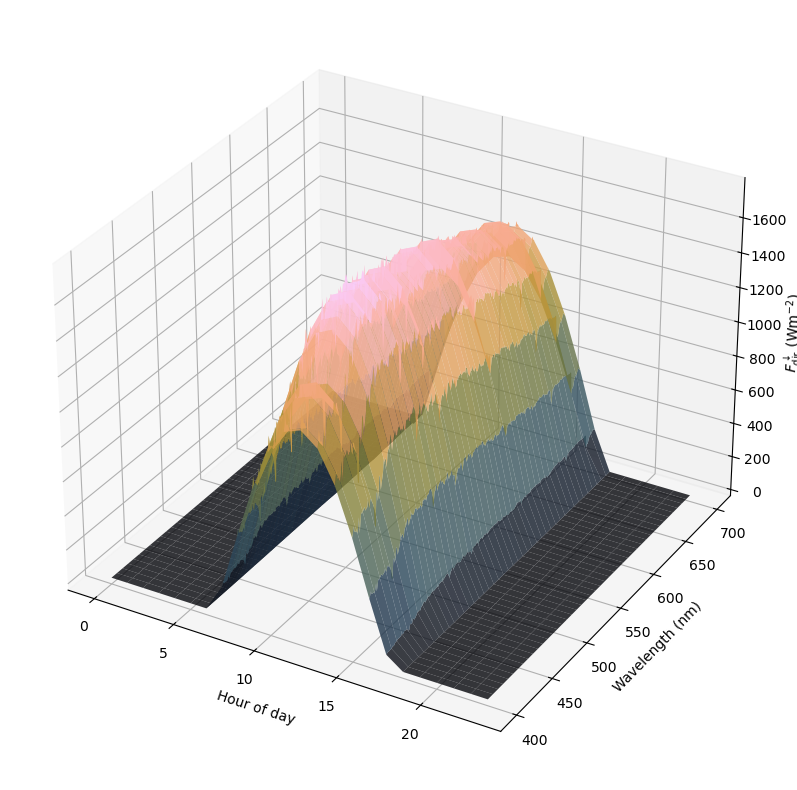

In [12]:
# Plot the results
from cmcrameri import cm

# make a 3d plot with time on the x-axis, wavelength on the y-axis, and irradiance on the z-axis
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.set_prop_cycle(
    color=cm.batlowK(np.linspace(0, 1, len(ds['wavelength'].values))),
)

x = np.arange(len(ds['time'].values))
y = ds['wavelength'].values
z = ds['edir'].values.T
X, Y = np.meshgrid(x, y)

ax.plot_surface(X, Y, z, cmap=cm.batlowK, edgecolor='none', alpha=0.8)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Wavelength (nm)')
ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')

plt.tight_layout()


In [14]:
ds

<xarray.Dataset> Size: 408kB
Dimensions:     (time: 24, wavelength: 301)
Coordinates:
    latitude    (time) float64 192B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    longitude   (time) float64 192B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * time        (time) datetime64[ns] 192B 2023-10-01 ... 2023-10-01T23:00:00
  * wavelength  (wavelength) float64 2kB 400.0 401.0 402.0 ... 698.0 699.0 700.0
Data variables:
    sza         (time, wavelength) float64 58kB 180.0 180.0 ... 180.0 180.0
    edir        (time, wavelength) float64 58kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    eglo        (time, wavelength) float64 58kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    edn         (time, wavelength) float64 58kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    eup         (time, wavelength) float64 58kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    enet        (time, wavelength) float64 58kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    albedo      (time, wavelength) float64 58kB nan nan nan nan ... nan nan nan
Attributes:
    generated_by:      pyradtran
    wavelength_range:  400.0 to 700.0 nm